In [1]:
from pathlib import Path
from IPython.display import display_markdown

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, wilcoxon

In [2]:
results_paths = [
    Path('../../results/quantum_entropy'),
    Path('../../results/kaoetal'),
    Path('../../results/local_global_surprise')
]
corpora = [
    'semeval',
    'humicroedit',
    'expunations',
    'cup',
    'joker_clef_en',
    'joker_clef_es',
    'HAHA@IberLEF2021',
    'HUHU@IberLEF2023',
    'joker_clef_fr',
    'joker_clef_pt',
    'clemencio',
    'puntuguese',
    'chumor'
]
metrics = [
    'QE-U + GloVe',
    'QE-I + GloVe',
    'QE-U + HF',
    'QE-I + HF',
    'local global surprise',
    'ambiguity',
    'distinctiveness'
]

In [3]:
dfs = []
for results_path in results_paths:
    for corpus in corpora:
        readpath = results_path / (corpus + '.jsonl')
        if readpath.exists():
            df = (pl.read_ndjson(readpath)
                    .with_columns(pl.lit(corpus).alias('corpus'))
                    .drop(['funniness', 'location', 'interpretation', 'char_count'], strict=False))
            if 'label' not in df.columns:
                df = df.with_columns(pl.lit(1).alias('label'))
            df = df.filter(pl.col('label') == 1)
            dfs.append(df)

combined_df = pl.concat(dfs, how='diagonal_relaxed')
df = (combined_df.group_by(['index', 'text', 'corpus'])
                 .agg([pl.col(m).drop_nulls().first() for m in metrics if m in combined_df.columns]))

datasets_enum = pl.Enum(corpora)
df = (df.with_columns(pl.lit('Humor').alias('label'))
     .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,local global surprise,ambiguity,distinctiveness,label
str,str,str,f64,f64,f64,f64,f64,f64,f64,str
"""semeval.hom_1782""","""He would promise to play golf,…","""semeval""",4.834548,-4.660677,0.531139,-0.302645,null,null,null,"""Humor"""
"""semeval.hom_1092""","""She memorized just what kind o…","""semeval""",4.869093,-4.728033,0.494887,-0.279211,null,null,null,"""Humor"""
"""semeval.hom_732""","""A thief fell and broke his leg…","""semeval""",5.20445,-5.102436,0.693557,-0.387741,null,null,null,"""Humor"""
"""semeval.hom_1822""","""'' Don't add too much water,''…","""semeval""",4.836979,-4.71029,0.603947,-0.375435,null,null,null,"""Humor"""
"""semeval.hom_1540""","""A streaker was found dead this…","""semeval""",4.964869,-4.828173,0.803768,-0.522328,null,null,null,"""Humor"""
…,…,…,…,…,…,…,…,…,…,…
"""chumor.1991""","""标题：我不管我不管我就要买这个！中年男子拿着玩具图册在父母坟…","""chumor""",5.41104,-5.368583,0.664815,-0.412854,null,null,null,"""Humor"""
"""chumor.478""","""标题：为了弘扬正能量，以后《天气预报》中的坏天气将不再播报。…","""chumor""",5.524758,-5.483973,0.741193,-0.46091,null,null,null,"""Humor"""
"""chumor.1319""","""标题：儿子是不是病了？怎么一踹就哭""","""chumor""",5.426916,-5.380133,0.592931,-0.359856,null,null,null,"""Humor"""


## Quantile analysis

In [4]:
melted_df = (df.unpivot(on=metrics,
                       index=['index', 'label', 'corpus'],
                       variable_name='metric')
               .drop_nulls())
melted_df

index,label,corpus,metric,value
str,str,str,str,f64
"""semeval.hom_1782""","""Humor""","""semeval""","""QE-U + GloVe""",4.834548
"""semeval.hom_1092""","""Humor""","""semeval""","""QE-U + GloVe""",4.869093
"""semeval.hom_732""","""Humor""","""semeval""","""QE-U + GloVe""",5.20445
"""semeval.hom_1822""","""Humor""","""semeval""","""QE-U + GloVe""",4.836979
"""semeval.hom_1540""","""Humor""","""semeval""","""QE-U + GloVe""",4.964869
…,…,…,…,…
"""puntuguese.5.3079.H""","""Humor""","""puntuguese""","""distinctiveness""",6.499971
"""puntuguese.5.3529.H""","""Humor""","""puntuguese""","""distinctiveness""",6.499975
"""puntuguese.5.815.H""","""Humor""","""puntuguese""","""distinctiveness""",6.499971


In [5]:
quantiles = (melted_df.group_by(['corpus', 'metric'])
                      .agg(pl.col('value').quantile(0.25).alias('Q1'),
                           pl.col('value').quantile(0.5).alias('Q2'),
                           pl.col('value').quantile(0.75).alias('Q3'))
                      .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
                      .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                                    (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))

with pl.Config(tbl_rows=60):
    display(quantiles.sort(pl.col('corpus').cast(datasets_enum)))

corpus,metric,Q1,Q2,Q3,IQR,F1,F2
str,str,f64,f64,f64,f64,f64,f64
"""semeval""","""QE-I + HF""",-0.364227,-0.326684,-0.290945,0.073282,-0.47415,-0.181021
"""semeval""","""QE-I + GloVe""",-4.94463,-4.868345,-4.78702,0.15761,-5.181045,-4.550605
"""semeval""","""QE-U + GloVe""",4.928157,5.00147,5.075655,0.147498,4.70691,5.296901
"""semeval""","""QE-U + HF""",0.534335,0.562347,0.600848,0.066512,0.434567,0.700617
"""humicroedit""","""QE-I + HF""",-0.396873,-0.366344,-0.335613,0.061259,-0.488762,-0.243724
"""humicroedit""","""QE-U + HF""",0.528869,0.559969,0.595487,0.066619,0.428941,0.695415
"""humicroedit""","""QE-U + GloVe""",5.05372,5.173874,5.264197,0.210478,4.738003,5.579914
"""humicroedit""","""QE-I + GloVe""",-5.183389,-5.077046,-4.94812,0.235269,-5.536293,-4.595217
"""expunations""","""QE-U + HF""",0.533401,0.559111,0.59734,0.063938,0.437494,0.693247


In [6]:
df_with_quantiles = melted_df.join(quantiles, on=['corpus', 'metric'])
is_low_outlier = (pl.col('value') < pl.col('F1'))
is_high_outlier = (pl.col('value') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(melted_df.columns)

with pl.Config(tbl_rows=13):
    display(df_no_outliers.group_by('corpus').len())

corpus,len
str,u64
"""HUHU@IberLEF2023""",986
"""expunations""",1224
"""puntuguese""",18177
"""joker_clef_pt""",737
"""joker_clef_en""",5191
"""semeval""",2635
"""chumor""",532
"""joker_clef_fr""",3856
"""humicroedit""",12311


## Plots

### Joint plot

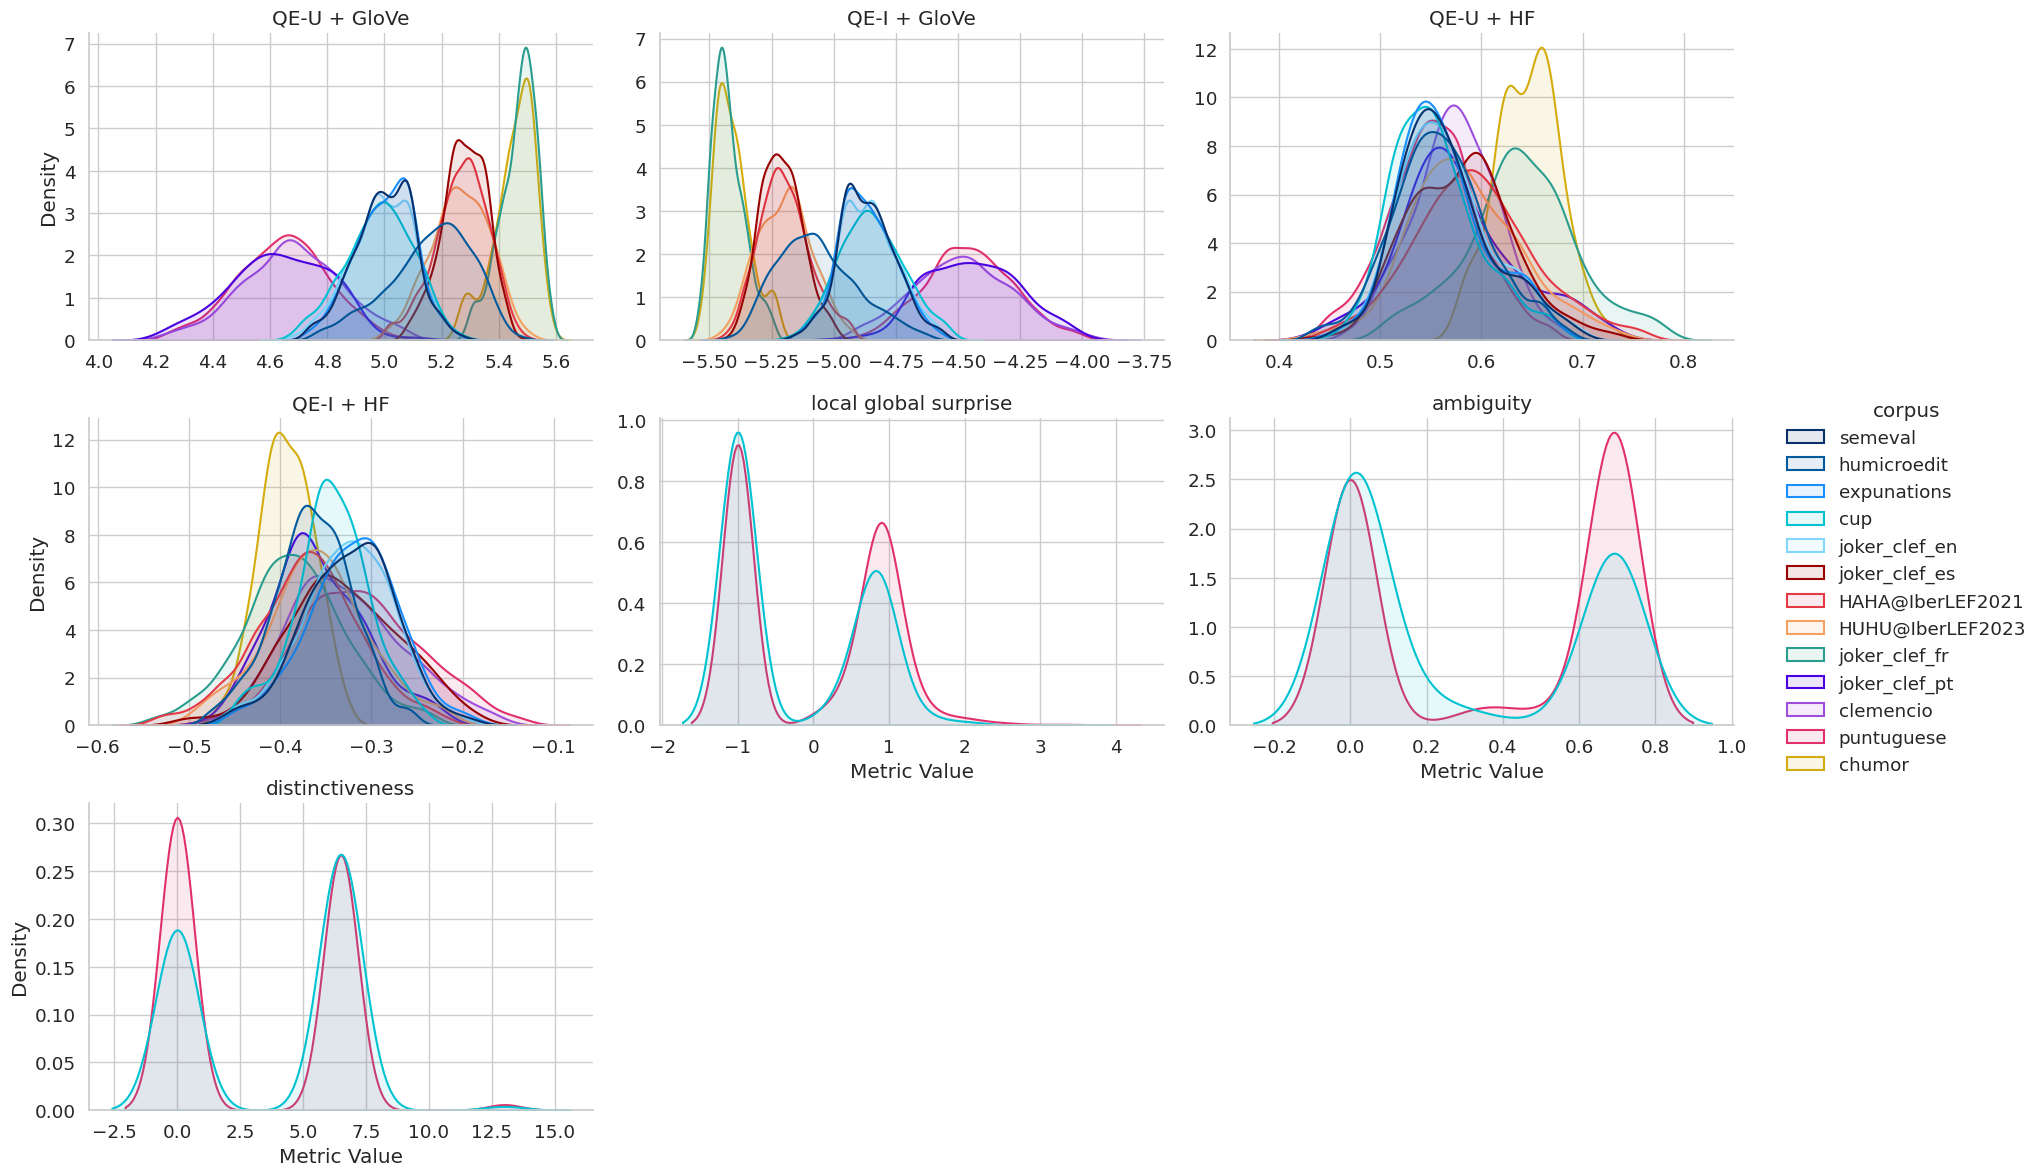

In [11]:
sns.set_theme(style="whitegrid", font_scale=1.2)

corpus_palette = {
    # English (Blue to Cyan spectrum)
    'semeval': '#08306B',         # Very Dark Blue
    'humicroedit': '#005A9C',     # Medium Blue
    'expunations': '#1890FF',     # Vibrant Blue
    'cup': '#00C2D1',             # Teal/Cyan
    'joker_clef_en': '#80D8FF',   # Light Cyan
    
    # Spanish (Red to Orange spectrum)
    'joker_clef_es': '#990000',   # Dark Crimson
    'HAHA@IberLEF2021': '#E63946',# Bright Red
    'HUHU@IberLEF2023': '#F4A261',# Sandy Orange
    
    # French (Green)
    'joker_clef_fr': '#2A9D8F',   # Persian Green
    
    # Portuguese (Purple to Pink spectrum)
    'joker_clef_pt': '#4A00E0',   # Deep Indigo
    'clemencio': '#9D4EDD',       # Bright Purple
    'puntuguese': '#E1306C',      # Magenta/Deep Pink
    
    # Mandarin Chinese (Golden/Amber)
    'chumor': '#D4AC0D'           # Dark Gold / Amber
}

g = sns.displot(df_no_outliers, x='value', hue='corpus', col='metric', col_wrap=3,
                kind='kde', common_norm=False, fill=True, height=4, aspect=1.5,
                facet_kws={'sharex': False, 'sharey': False}, palette=corpus_palette, alpha=0.1, linewidth=1.5)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Metric Value", "Density")
plt.show()

## Statistical tests (No outliers)